In [136]:
import pandas as pd
import seaborn as sna
import numpy as np
import matplotlib.pyplot as plt

### Load Data

In [137]:
df = pd.read_csv('Cars.csv')

### Initial Inspection

In [138]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [139]:
df.shape

(23906, 16)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


### Data Cleaning

In [141]:
df.describe()

,Annual Income,Price ($),Phone
count,2.390600e+04,23906.000000,2.390600e+04
mean,8.308403e+05,28090.247846,7.497741e+06
std,7.200064e+05,14788.687608,8.674920e+05
min,1.008000e+04,1200.000000,6.000101e+06
25%,3.860000e+05,18001.000000,6.746495e+06
50%,7.350000e+05,23000.000000,7.496198e+06
75%,1.175750e+06,34000.000000,8.248146e+06
max,1.120000e+07,85800.000000,8.999579e+06


In [142]:
df.columns = df.columns.str.strip().str.replace(" ","_")

In [143]:
for i in df.columns:
    print(f"colum's name {i} -> {df[i].nunique()}")

colum's name Car_id -> 23906
colum's name Date -> 612
colum's name Customer_Name -> 3021
colum's name Gender -> 2
colum's name Annual_Income -> 2508
colum's name Dealer_Name -> 28
colum's name Company -> 30
colum's name Model -> 154
colum's name Engine -> 2
colum's name Transmission -> 2
colum's name Color -> 3
colum's name Price_($) -> 870
colum's name Dealer_No -> 7
colum's name Body_Style -> 5
colum's name Phone -> 23804
colum's name Dealer_Region -> 7


In [144]:
print(df.isnull().sum())

df[df['Customer_Name'].isnull()]

Car_id           0
Date             0
Customer_Name    1
Gender           0
Annual_Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price_($)        0
Dealer_No        0
Body_Style       0
Phone            0
Dealer_Region    0
dtype: int64


,Car_id,Date,Customer_Name,Gender,Annual_Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price_($),Dealer_No,Body_Style,Phone,Dealer_Region
7564,C_CND_007565,11/5/2022,NaN,Male,680000,Saab-Belle Dodge,Dodge,Ram Pickup,DoubleÂ Overhead Camshaft,Auto,Pale White,45000,60504-7114,Hardtop,7203103,Aurora


In [145]:
df['Customer_Name'] = df['Customer_Name'].fillna('Unknown')

In [146]:
# Date (obj -> datetime)
df['Date'] = pd.to_datetime(df['Date'],errors = 'coerce')

In [147]:
# convert DT from object to category 
cat_col = ['Gender','Dealer_Name','Company','Model','Engine','Transmission','Color','Body_Style','Dealer_Region']
for col in cat_col:
    df[col] = df[col].astype('category')

In [148]:
# convert phone from Int64 to string|object
df['Phone'] = df['Phone'].astype('str')

In [149]:
df['Engine'] = df['Engine'].str.replace("Â","")

### Exploratory Data Analysis

In [150]:
df.describe()

,Date,Annual_Income,Price_($)
count,23906,2.390600e+04,23906.000000
mean,2023-03-01 14:28:10.822387456,8.308403e+05,28090.247846
min,2022-01-02 00:00:00,1.008000e+04,1200.000000
25%,2022-09-20 00:00:00,3.860000e+05,18001.000000
50%,2023-03-13 00:00:00,7.350000e+05,23000.000000
75%,2023-09-08 00:00:00,1.175750e+06,34000.000000
max,2023-12-31 00:00:00,1.120000e+07,85800.000000
std,NaN,7.200064e+05,14788.687608


In [151]:
# Outliers Detection 
def detect_outliers(df,column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)

    IQR = Q3 - Q1
    
    upper_bound = Q3 + (1.5 * IQR )
    lower_bound = Q1 - (1.5 * IQR )

    # df_clean = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    return upper_bound,lower_bound

In [152]:
# Annual Income before Transformation
upper_Annual_Income , lower_Annual_Income = detect_outliers(df,"Annual_Income")
print(f"the lower income is {lower_Annual_Income} and the upper Annual Income is {upper_Annual_Income} ")

print(f"the min is {df["Annual_Income"].min()} and the max is {df["Annual_Income"].max()}")

the lower income is -798625.0 and the upper Annual Income is 2360375.0 
the min is 10080 and the max is 11200000


In [153]:
# Price before Transformation
upper_Annual_Income , lower_Annual_Income = detect_outliers(df,"Price_($)")
print(f"the lower price is {lower_Annual_Income} and the upper price is {upper_Annual_Income} ")

print(f"the min is {df["Price_($)"].min()} and the max is {df["Price_($)"].max()}")

the lower price is -5997.5 and the upper price is 57998.5 
the min is 1200 and the max is 85800


In [156]:
df.describe()

,Date,Annual_Income,Price_($),Log_Annual_Income,Log_Price
count,23906,2.390600e+04,23906.000000,23906.000000,23906.000000
mean,2023-03-01 14:28:10.822387456,8.308403e+05,28090.247846,12.799485,10.125823
min,2022-01-02 00:00:00,1.008000e+04,1200.000000,9.218309,7.090077
25%,2022-09-20 00:00:00,3.860000e+05,18001.000000,12.863593,9.798183
50%,2023-03-13 00:00:00,7.350000e+05,23000.000000,13.507626,10.043249
75%,2023-09-08 00:00:00,1.175750e+06,34000.000000,13.977417,10.434116
max,2023-12-31 00:00:00,1.120000e+07,85800.000000,16.231424,11.359774
std,NaN,7.200064e+05,14788.687608,1.810626,0.473406


### Univariate Analysis

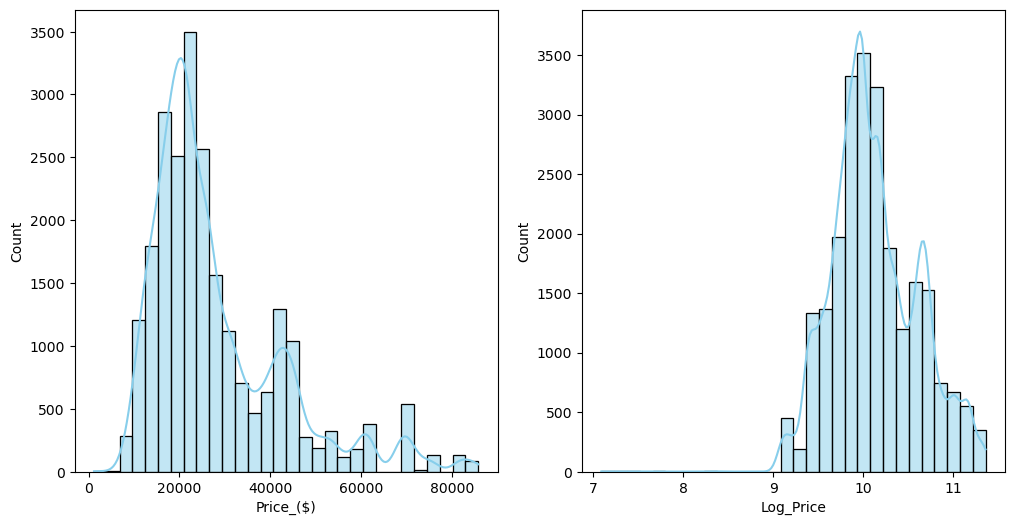

In [168]:
# للتأكد من توزيع الداتا transformation قمت بتمثيل ال 
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.histplot(data=df, x='Price_($)', bins=30, kde=True, color='skyblue')
plt.subplot(1,2,2)
sns.histplot(data=df, x='Log_Price', bins=30, kde=True, color='skyblue')

plt.show()

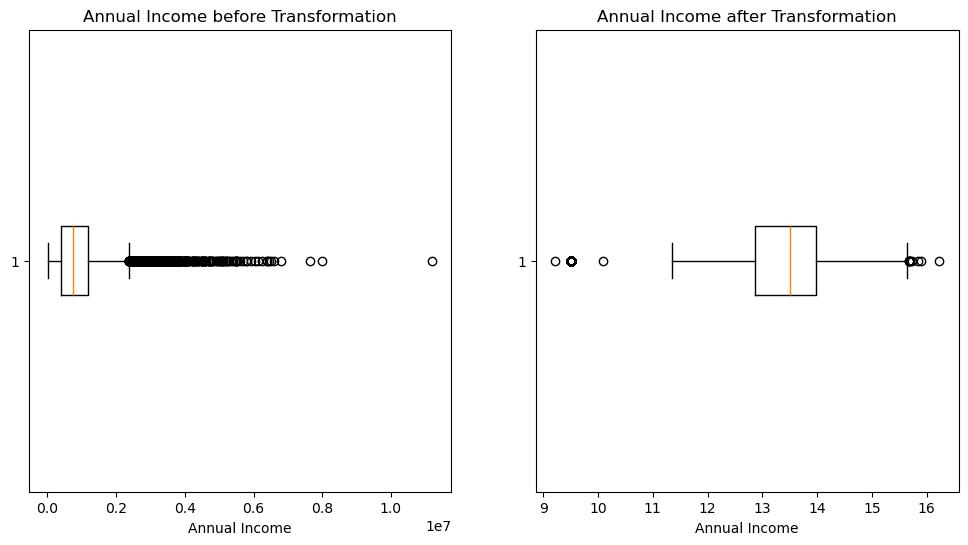

In [158]:
# box plot on Annual Income before and After Transformation
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.boxplot(df["Annual_Income"],vert=False)
plt.title("Annual Income before Transformation")
plt.xlabel("Annual Income")

plt.subplot(1,2,2)
plt.boxplot(df["Log_Annual_Income"],vert=False)
plt.title("Annual Income after Transformation")
plt.xlabel("Annual Income")

plt.show()

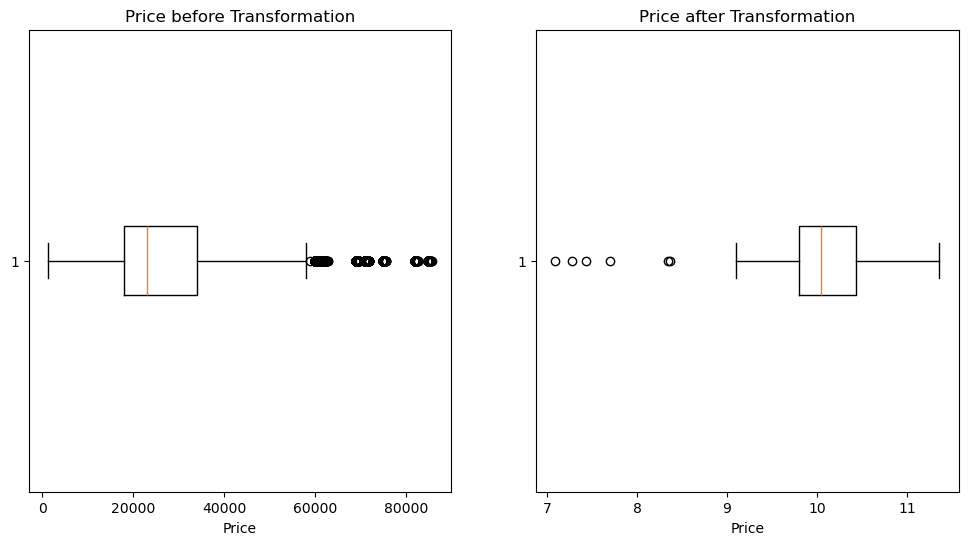

In [159]:
# box plot on Price before and After Transformation
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.boxplot(df["Price_($)"],vert=False)
plt.title("Price before Transformation")
plt.xlabel("Price")

plt.subplot(1,2,2)
plt.boxplot(df["Log_Price"],vert=False)
plt.title("Price after Transformation")
plt.xlabel("Price")

plt.show()

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_19108\1731692227.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df["Price_Category"] == category]["Price_($)"] for category in labels] , labels = labels, patch_artist=True, boxprops=dict(facecolor='skyblue'))


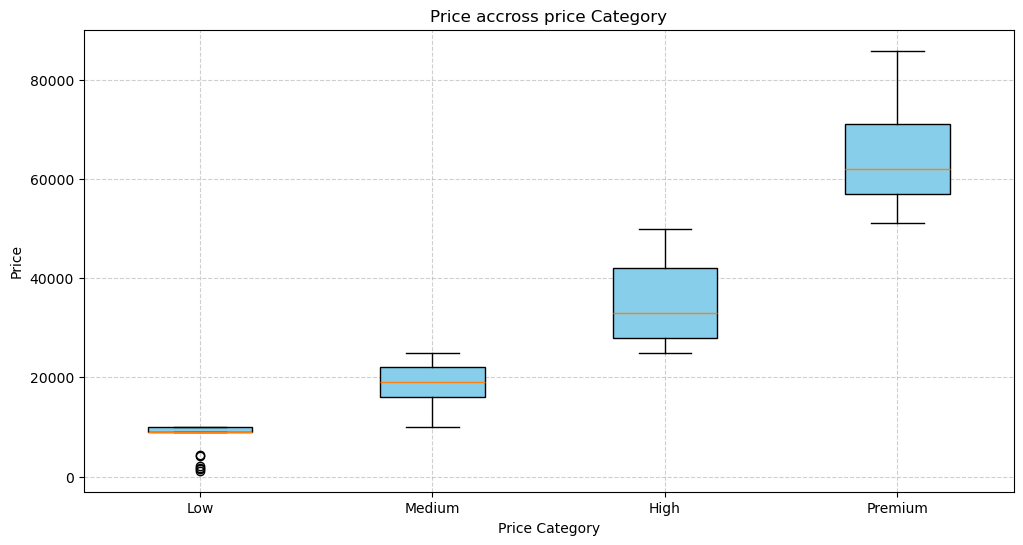

In [160]:
bins = [0,10000,25000,50000,100000]
labels = ["Low" , "Medium" , "High" , "Premium"]

df["Price_Category"] = pd.cut(df["Price_($)"],bins=bins , labels=labels)

plt.figure(figsize=(12,6))
plt.boxplot([df[df["Price_Category"] == category]["Price_($)"] for category in labels] , labels = labels, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title("Price accross price Category")
plt.xlabel("Price Category")
plt.ylabel("Price")
plt.grid(True,linestyle='--',alpha = 0.6)
plt.show()

### Bivariate Analysis

In [162]:
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

                   Annual_Income  Price_($)  Log_Annual_Income  Log_Price
Annual_Income           1.000000   0.012065           0.772745   0.016255
Price_($)               0.012065   1.000000           0.008466   0.958556
Log_Annual_Income       0.772745   0.008466           1.000000   0.013980
Log_Price               0.016255   0.958556           0.013980   1.000000


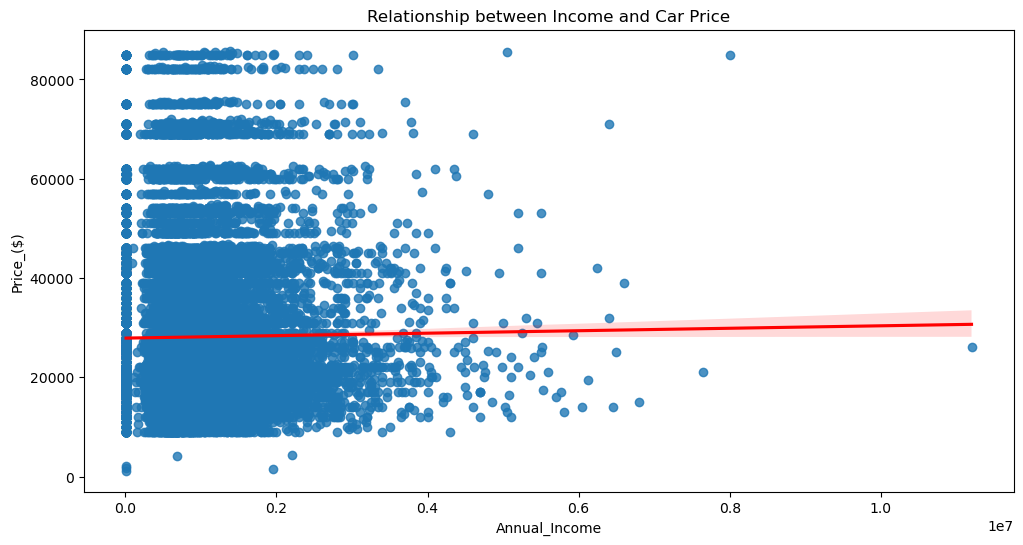

In [169]:
plt.figure(figsize = (12,6))

sns.regplot(x='Annual_Income', y='Price_($)', data=df, line_kws={"color": "red"})
plt.title('Relationship between Income and Car Price')

plt.show()

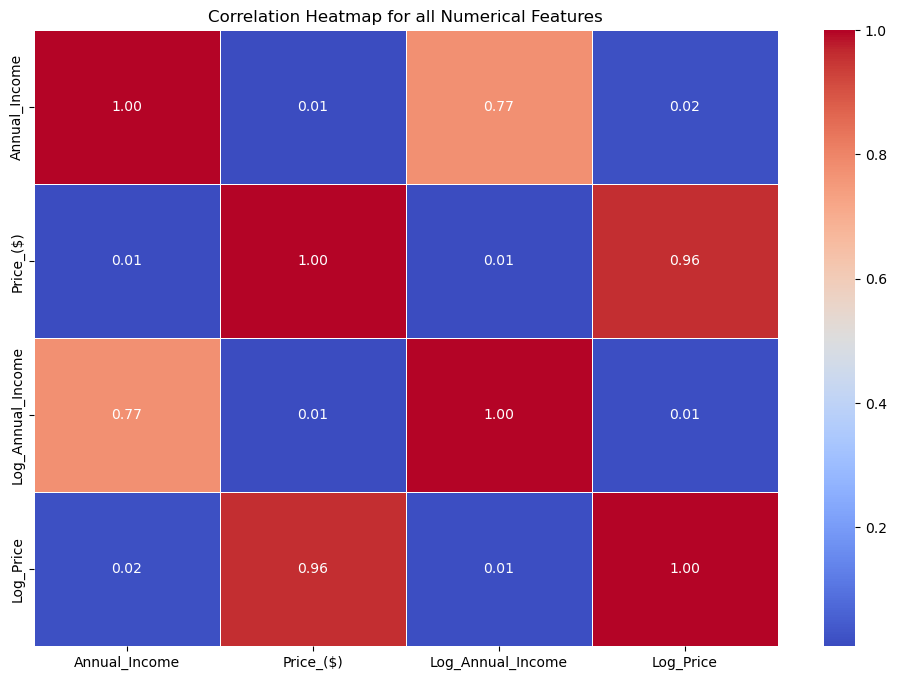

In [166]:
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. بنرسم الـ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap for all Numerical Features')
plt.show()

### Save Data

In [165]:
# حفظ البيانات بعد التنظيف
# df.to_csv('car_sales_cleaned.csv', index=False, encoding='utf-8-sig')